# best model is catboost regression 

In [23]:
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor

In [24]:
df = pd.read_csv('../data/processed/preprocessed.csv')

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
# CatBoost Regression Model

from catboost import CatBoostRegressor

model = CatBoostRegressor(random_state=42, verbose=0)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cat_mae = mean_absolute_error(y_test, y_pred)
cat_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
cat_r2 = r2_score(y_test, y_pred)

print("MAE in CatBoost Regression:", cat_mae)
print("RMSE in CatBoost Regression:", cat_rmse)
print("R2  in CatBoost Regression:", cat_r2)


MAE in CatBoost Regression: 73550.42318420728
RMSE in CatBoost Regression: 143389.99022303123
R2  in CatBoost Regression: 0.8639956578680758


# hyperparameter tuning

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

param_grid = {
    "iterations": [200, 400],
    "depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "l2_leaf_reg": [3, 5]
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre...42, verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [4, 6, ...], 'iterations': [200, 400], 'l2_leaf_reg': [3, 5], 'learning_rate': [0.05, 0.1]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multipl

In [27]:
print("Best Parameters:")
print(search.best_params_)

print("\nBest CV RMSE:")
print(-search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 6}

Best CV RMSE:
143704.83664014598


In [28]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 79128.15248455422
RMSE: 151552.71002590418
R2: 0.8480703570456563


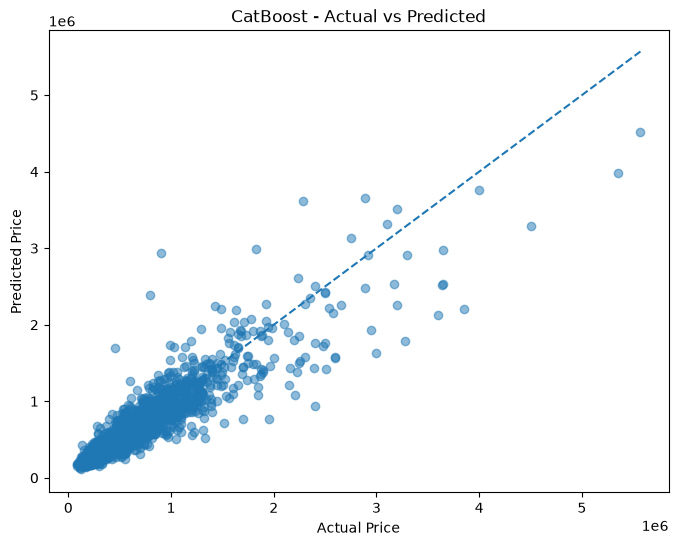

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("CatBoost - Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.savefig('../reports/images/catboost_actual_vs_predicted.png', dpi=300)
plt.show()

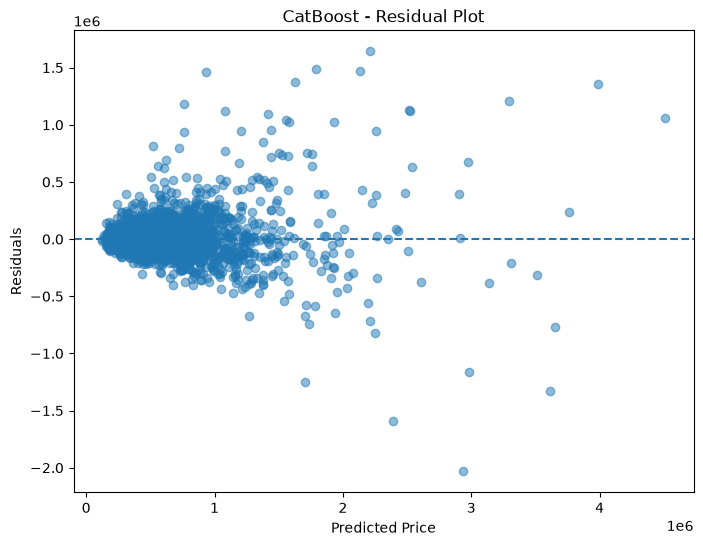

<Figure size 640x480 with 0 Axes>

In [30]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("CatBoost - Residual Plot")

plt.show()
plt.savefig('../reports/images/catboost_residual_plot.png', dpi=300)

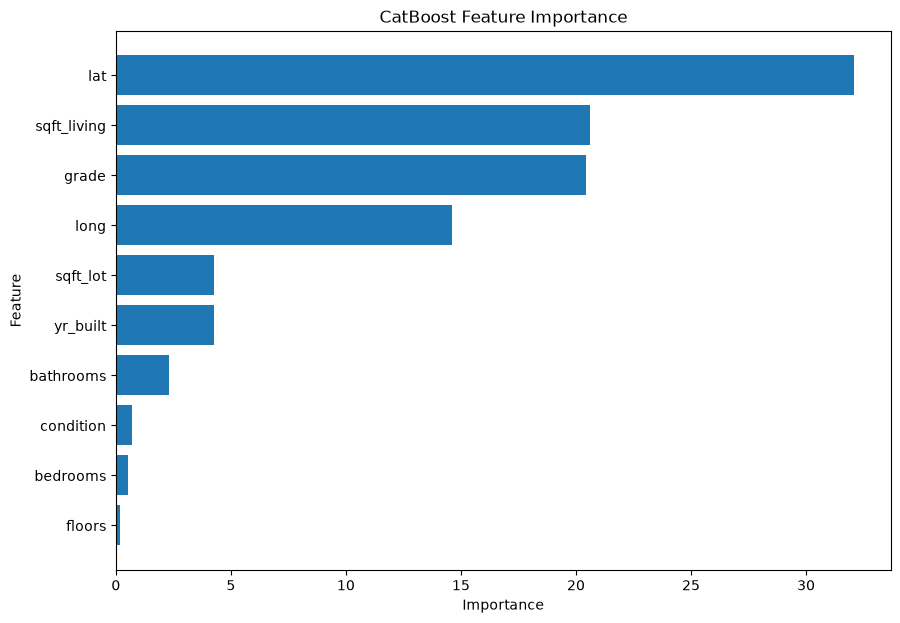

<Figure size 640x480 with 0 Axes>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

plt.savefig('../reports/images/catboost_feature_importance.png', dpi=300)

In [34]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/best_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [35]:
df


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,yr_built,lat,long,price
0,3,1.00,1180,5650,1.0,3,7,1955,47.5112,-122.257,221900.0
1,3,2.25,2570,7242,2.0,3,7,1951,47.7210,-122.319,538000.0
2,2,1.00,770,10000,1.0,3,6,1933,47.7379,-122.233,180000.0
3,4,3.00,1960,5000,1.0,5,7,1965,47.5208,-122.393,604000.0
4,3,2.00,1680,8080,1.0,3,8,1987,47.6168,-122.045,510000.0
...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,3,8,2009,47.6993,-122.346,360000.0
21609,4,2.50,2310,5813,2.0,3,8,2014,47.5107,-122.362,400000.0
21610,2,0.75,1020,1350,2.0,3,7,2009,47.5944,-122.299,402101.0
21611,3,2.50,1600,2388,2.0,3,8,2004,47.5345,-122.069,400000.0
